# ESG INVESTING PROJECT
## ALBERTO GALLINO

In [ ]:
#import need libraries
import numpy as np
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [ ]:
#change the required path
#I upload the file that I got from the World Bank site
# From the dataset I choose 15 countries from different areas
path = "P_Data_Extract_From_Environment_Social_and_Governance_(ESG)_Data.xlsx"
with pd.option_context('future.no_silent_downcasting', True):
    df = pd.read_excel(
        path
        ).replace(
            {'..':pd.NA}
        ).dropna(
            how="all" # remove all empty rows
        ).iloc[:-2].convert_dtypes()

countries = np.array(
    [
    "Finland",
    "Zimbabwe",
    "United States",
    "Norway",
    "Sierra Leone",
    "Mexico",
    "United Kingdom",
    "China",
    "Japan",
    "Australia",
    "Viet Nam",
    "Uruguay",
    "Austria",
    "Germany",
    "Canada"
    ]
)
#select given countries
df = df[df["Country Name"].isin(countries)]
data = df.columns.tolist()
# convert to digi years
years = [item.split(' ')[0] for item in data[4:]]
df.columns = data[:4] + years
display(df)

,Country Name,Country Code,Series Name,Series Code,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
568,Australia,AUS,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,<NA>,<NA>
569,Australia,AUS,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,<NA>,<NA>
570,Australia,AUS,Adjusted savings: natural resources depletion ...,NY.ADJ.DRES.GN.ZS,1.803821,1.252037,1.676014,1.781078,2.380902,2.389843,3.068923,6.223595,<NA>,<NA>
571,Australia,AUS,Adjusted savings: net forest depletion (% of GNI),NY.ADJ.DFOR.GN.ZS,0.0,0.0,0.0,0.0,0.0,0.0,0.149635,0.124411,<NA>,<NA>
572,Australia,AUS,Agricultural land (% of land area),AG.LND.AGRI.ZS,48.738399,45.314424,44.539926,48.340618,46.658095,47.123772,46.25248,47.259237,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14550,Zimbabwe,ZWE,Terrestrial and marine protected areas (% of t...,ER.PTD.TOTL.ZS,<NA>,<NA>,27.214542,27.214585,27.214585,27.214747,27.214747,27.214747,27.214747,<NA>
14551,Zimbabwe,ZWE,Tree Cover Loss (hectares),AG.LND.FRLS.HA,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
14552,Zimbabwe,ZWE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,4.77,5.412,5.918,6.349,6.767,7.37,8.651,9.54,9.256,9.116
14553,Zimbabwe,ZWE,Unmet need for contraception (% of married wom...,SP.UWT.TFRT,10.382129,10.4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
value = "2019" # I took  a value casually
# Extract the unique codes
codes = df["Series Code"].unique().tolist()
countries = df["Country Name"].unique().tolist()
# initialize the zscore to NaN and add the metric of zscore
zscores = pd.DataFrame(pd.NA, columns=["Country"] + codes, index=range(len(countries)))
zscores["Country"] = countries
for code in codes:
    code_selected = df[df["Series Code"] == code][value].reset_index(drop=True)
    zscores[code] = (code_selected-code_selected.mean())/code_selected.std()
columns_names =df.set_index('Series Code')['Series Name'].to_dict()
display(zscores.rename(columns_names, axis="columns"))

,Country,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: net forest depletion (% of GNI),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)","Annual freshwater withdrawals, total (% of internal resources)","Annualized average growth rate in per capita real survey mean consumption or income, total population (%)","Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",...,"School enrollment, primary (% gross)","School enrollment, primary and secondary (gross), gender parity index (GPI)",Scientific and technical journal articles,Standardised Precipitation-Evapotranspiration Index,Strength of legal rights index (0=weak to 12=strong),Terrestrial and marine protected areas (% of total territorial area),Tree Cover Loss (hectares),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Unmet need for contraception (% of married women ages 15-49),Voice and Accountability: Estimate
0,Australia,0.474279,0.375359,0.390935,-0.341679,0.316793,-0.355233,-0.924745,<NA>,-0.446292,...,-0.383439,-1.269481,-0.255025,-1.659735,1.678293,1.052764,1.395703,0.335673,<NA>,0.608663
1,Austria,0.474279,0.375359,-0.693406,-0.323573,-0.32035,-0.428308,-0.521646,<NA>,-0.529572,...,-0.241018,-0.760321,-0.50198,0.111958,-1.032796,0.94446,-0.655566,0.023935,<NA>,0.667505
2,Canada,0.474279,0.375359,-0.483035,-0.341679,-1.412036,-0.383894,-1.007968,-0.081948,-0.456545,...,-0.60126,-0.139488,-0.22431,0.499003,0.903696,-0.780872,2.043589,0.611042,<NA>,0.74892
3,China,-0.216679,0.375359,-0.390876,-0.341679,0.671098,-0.00865,0.921982,<NA>,-0.530803,...,-0.560882,0.276412,2.843131,-0.451568,-1.420094,-0.202403,-0.071749,0.023935,<NA>,-1.92649
4,Finland,0.474279,0.375359,-0.70964,-0.341679,-1.367524,-0.338959,-0.861144,<NA>,-0.65991,...,-0.44161,1.376825,-0.513886,1.020323,-0.258199,-0.343314,-0.332651,1.130607,<NA>,0.865195
5,Germany,0.474279,0.375359,-0.707128,-0.341679,0.341287,-0.446329,1.059849,1.544213,-0.45729,...,-0.171353,-1.230246,0.033211,-0.908217,-0.258199,1.787158,-0.561576,-0.713847,<NA>,0.682189
6,Japan,0.474279,0.375359,-0.71333,-0.341679,-1.135811,-0.429236,0.617817,<NA>,-0.12099,...,-0.161885,-0.082145,-0.00983,-0.642264,-0.645497,-0.597261,-0.633221,-1.124303,<NA>,0.311265
7,Mexico,-0.042263,0.358261,0.056456,-0.341679,0.415142,-0.272619,0.964211,<NA>,-0.194072,...,0.05878,1.381657,-0.472111,-0.571512,1.290994,0.147466,-0.285363,-0.537195,<NA>,-0.494628
8,Norway,0.474279,0.375359,1.418341,-0.341679,-1.570877,-0.378012,-1.062373,-0.619734,-0.279951,...,-0.484527,-0.922697,-0.506209,1.187522,-0.645497,-1.019393,-0.616325,-0.428086,<NA>,0.94421
9,Sierra Leone,-2.856409,-2.928892,2.437375,3.321562,0.639138,3.50574,-1.117189,<NA>,2.696117,...,3.245125,<NA>,-0.575423,-0.823629,-0.645497,-1.161394,-0.476857,-0.683193,<NA>,-0.616161


In [ ]:
weights = {
        # Environmental (40%)
        # Climate & Emissions (15%)
        'EN.ATM.CO2E.PC': 0.03,  # CO2 emissions (metric tons per capita)
        'EN.ATM.METH.PC': 0.03,  # Methane emissions
        'EN.ATM.NOXE.PC': 0.03,  # Nitrous oxide emissions
        'EG.USE.COMM.FO.ZS': 0.03,  # Fossil fuel energy consumption
        'EN.CLC.GHGR.MT.CE': 0.03,  # GHG net emissions/removals

        # Resource Management (10%)
        'EG.EGY.PRIM.PP.KD': 0.02,  # Energy intensity level
        'EG.IMP.CONS.ZS': 0.02,  # Energy imports dependency
        'EG.FEC.RNEW.ZS': 0.02,  # Renewable energy consumption
        'EG.ELC.RNEW.ZS': 0.02,  # Renewable electricity output
        'ER.H2O.FWTL.ZS': 0.02,  # Annual freshwater withdrawals

        # Biodiversity & Land Use (10%)
        'AG.LND.FRST.ZS': 0.02,  # Forest area
        'AG.LND.AGRI.ZS': 0.02,  # Agricultural land
        'ER.PTD.TOTL.ZS': 0.02,  # Protected areas
        'AG.LND.FRLS.HA': 0.02,  # Tree cover loss (inverted)
        'EN.MAM.THRD.NO': 0.02,  # Mammal species threatened (inverted)

        # Pollution & Waste (5%)
        'EN.ATM.PM25.MC.M3': 0.0125,  # PM2.5 air pollution
        'ER.H2O.FWST.ZS': 0.0125,  # Water stress level
        'EN.H2O.BDYS.ZS': 0.0125,  # Bodies of water with good quality
        'EG.CFT.ACCS.ZS': 0.0125,  # Access to clean fuels

        # Social (30%)
        # Health & Wellbeing (10%)
        'SP.DYN.LE00.IN': 0.02,  # Life expectancy
        'SH.DYN.MORT': 0.02,  # Mortality rate (inverted)
        'SH.MED.BEDS.ZS': 0.02,  # Hospital beds
        'SN.ITK.DEFC.ZS': 0.02,  # Prevalence of undernourishment (inverted)
        'SH.STA.OWAD.ZS': 0.02,  # Prevalence of overweight (inverted)

        # Education & Skills (5%)
        'SE.ADT.LITR.ZS': 0.01,  # Literacy rate
        'SE.XPD.TOTL.GB.ZS': 0.01,  # Government expenditure on education
        'SE.PRM.ENRR': 0.01,  # School enrollment (primary)
        'SE.ENR.PRSC.FM.ZS': 0.01,  # School enrollment gender parity
        'IP.JRN.ARTC.SC': 0.01,  # Scientific journal articles

        # Equity & Inclusion (10%)
        'SI.POV.GINI': 0.0167,  # Gini index (inverted)
        'SI.DST.FRST.20': 0.0167,  # Income share held by lowest 20%
        'SI.POV.NAHC': 0.0167,  # Poverty headcount (inverted)
        'SL.TLF.ACTI.ZS': 0.0167,  # Labor force participation
        'SL.TLF.CACT.FM.ZS': 0.0167,  # Ratio of female to male labor force
        'SG.GEN.PARL.ZS': 0.0167,  # Proportion of seats held by women

        # Basic Services (5%)
        'EG.ELC.ACCS.ZS': 0.0125,  # Access to electricity
        'SH.H2O.SMDW.ZS': 0.0125,  # Safely managed drinking water
        'SH.STA.SMSS.ZS': 0.0125,  # Safely managed sanitation
        'IT.NET.USER.ZS': 0.0125,  # Internet usage

        # Governance (30%)
        # Institutional Quality (20%)
        'CC.EST': 0.0333,  # Control of Corruption
        'GE.EST': 0.0333,  # Government Effectiveness
        'RQ.EST': 0.0333,  # Regulatory Quality
        'RL.EST': 0.0333,  # Rule of Law
        'VA.EST': 0.0333,  # Voice and Accountability
        'PV.EST': 0.0333,  # Political Stability

        # Economic Governance (10%)
        'NY.GDP.MKTP.KD.ZG': 0.025,  # GDP growth
        'GB.XPD.RSDV.GD.ZS': 0.025,  # R&D expenditure
        'IP.PAT.RESD': 0.025,  # Patent applications
        'IC.LGL.CRED.XQ': 0.025  # Strength of legal rights
    }



In [ ]:
# add Z-scored to distinguish values
df_copy = df.copy()
df_copy = df_copy[df_copy["Series Code"].isin(weights.keys())]
new_columns = np.char.add(years, ' Z-scored')
df_copy[new_columns] = pd.NA
#add weight column
df_copy["weights"] = df_copy["Series Code"].map(weights)
#calculate z-score for every year add weights
for name in weights.keys():
    selected = df_copy[df_copy["Series Code"] == name][years]
    zscore = (selected - selected.mean())/selected.std()
    df_copy.loc[zscore.index, new_columns] = zscore.values
df_copy

,Country Name,Country Code,Series Name,Series Code,2014,2015,2016,2017,2018,2019,...,2015 Z-scored,2016 Z-scored,2017 Z-scored,2018 Z-scored,2019 Z-scored,2020 Z-scored,2021 Z-scored,2022 Z-scored,2023 Z-scored,weights
568,Australia,AUS,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,...,0.522541,0.507853,0.495172,0.483506,0.474279,0.466223,0.458629,<NA>,<NA>,0.0125
569,Australia,AUS,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,...,0.382961,0.378349,0.374423,0.376434,0.375359,0.371688,0.372487,<NA>,<NA>,0.0125
572,Australia,AUS,Agricultural land (% of land area),AG.LND.AGRI.ZS,48.738399,45.314424,44.539926,48.340618,46.658095,47.123772,...,0.236978,0.210809,0.362356,0.300947,0.316793,0.289397,0.330011,<NA>,<NA>,0.0200
574,Australia,AUS,"Annual freshwater withdrawals, total (% of int...",ER.H2O.FWTL.ZS,3.752642,1.873984,2.159146,2.450943,2.506098,2.140244,...,-0.957029,-0.92914,-0.905771,-0.891928,-0.924745,-0.955928,<NA>,<NA>,<NA>,0.0200
578,Australia,AUS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,16.155745,16.198458,16.320331,16.14915,15.865714,15.599045,...,1.678015,1.725919,1.723254,1.677149,1.727211,1.8166,<NA>,<NA>,<NA>,0.0300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14547,Zimbabwe,ZWE,Scientific and technical journal articles,IP.JRN.ARTC.SC,269.02,269.92,316.99,334.71,406.23,431.62,...,-0.622117,-0.616683,-0.6083,-0.592426,-0.573279,-0.563459,<NA>,<NA>,<NA>,0.0100
14549,Zimbabwe,ZWE,Strength of legal rights index (0=weak to 12=s...,IC.LGL.CRED.XQ,5.0,5.0,5.0,5.0,5.0,6.0,...,-0.592589,-0.592589,-0.612287,-0.612287,-0.258199,<NA>,<NA>,<NA>,<NA>,0.0250
14550,Zimbabwe,ZWE,Terrestrial and marine protected areas (% of t...,ER.PTD.TOTL.ZS,<NA>,<NA>,27.214542,27.214585,27.214585,27.214747,...,<NA>,0.964927,0.838635,0.838635,0.843683,0.711428,0.694543,0.693282,<NA>,0.0200
14551,Zimbabwe,ZWE,Tree Cover Loss (hectares),AG.LND.FRLS.HA,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0200


In [ ]:
esg_scores = pd.DataFrame(pd.NA, index=range(15), columns=["Country"] + years)
#some nasty warning due to pandas that I removedin this way
esg_scores["Country"] = esg_scores["Country"].astype(str)
for ind,(country, datas) in enumerate(df_copy.groupby("Country Name")):
    #calcula esg score as multiplication of matrix z-score x weights
    esg_score = datas[new_columns].multiply(datas["weights"], axis=0).sum().tolist()
    esg_score.insert(0, country)
    esg_scores.iloc[ind] = esg_score
esg_scores

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Australia,0.357346,0.309149,0.333795,0.315056,0.371921,0.361471,0.363633,0.131525,0.215005,0.005262
1,Austria,0.102072,0.121134,0.087769,0.096202,0.071181,0.092559,0.10761,0.160687,0.192163,0.002345
2,Canada,0.272586,0.284092,0.23949,0.238349,0.216055,0.254536,0.189019,0.189925,0.147716,0.009556
3,China,-0.141244,-0.191802,-0.1429,-0.096618,-0.079395,-0.11988,-0.081856,-0.116447,-0.254648,0.000423
4,Finland,0.184397,0.192405,0.230144,0.231481,0.180141,0.230243,0.280117,0.231476,0.211947,0.015055
5,Germany,0.190586,0.194882,0.205499,0.160046,0.127414,0.157122,0.160814,0.16414,0.167553,0.001006
6,Japan,0.111207,0.135917,0.052843,0.080191,0.077653,0.04347,0.056304,0.067898,0.07573,-0.015252
7,Mexico,-0.324318,-0.302569,-0.326342,-0.396606,-0.318075,-0.370895,-0.411634,-0.335133,-0.273813,-0.050049
8,Norway,0.033983,0.070863,0.081467,0.095351,0.042334,0.085898,0.152663,0.121804,0.231202,0.013308
9,Sierra Leone,-0.457726,-0.534358,-0.458304,-0.434837,-0.401708,-0.402614,-0.455561,-0.268111,-0.396542,0.0166


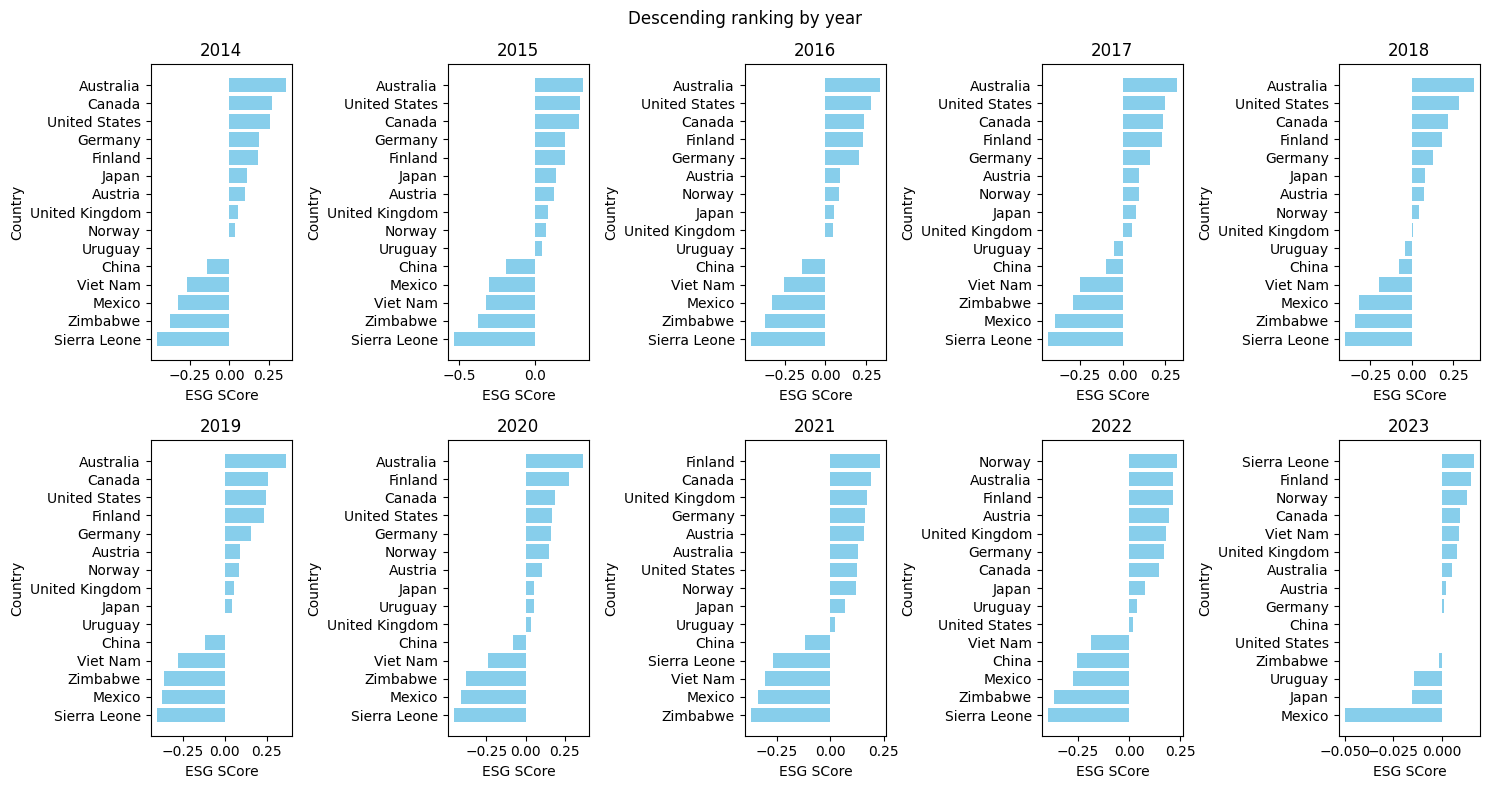

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
fig.suptitle("Descending ranking by year")
axes = axes.flatten()

# Loop through each year and create a subplot
for i, year in enumerate(years):
    # Sort by each year's values
    esg_sorted = esg_scores.sort_values(by=year, ascending=True)
    axes[i].barh(esg_sorted["Country"], esg_sorted[year], color="skyblue")
    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("ESG SCore")
    axes[i].set_ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
df_copy = df.copy()
uniform_weights=dict.fromkeys(df_copy["Series Code"].unique(),  1/len(df_copy["Series Code"].unique()))
new_columns = np.char.add(years, ' Z-scored')
df_copy[new_columns] = pd.NA
#add weight column to be unifrom
df_copy["weights"] = df_copy["Series Code"].map(uniform_weights)
for name in uniform_weights.keys():
    selected = df_copy[df_copy["Series Code"] == name][years]
    zscore = (selected - selected.mean())/selected.std()
    df_copy.loc[zscore.index, new_columns] = zscore.values
df_copy

,Country Name,Country Code,Series Name,Series Code,2014,2015,2016,2017,2018,2019,...,2015 Z-scored,2016 Z-scored,2017 Z-scored,2018 Z-scored,2019 Z-scored,2020 Z-scored,2021 Z-scored,2022 Z-scored,2023 Z-scored,weights
568,Australia,AUS,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,...,0.522541,0.507853,0.495172,0.483506,0.474279,0.466223,0.458629,<NA>,<NA>,0.014085
569,Australia,AUS,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,100.0,100.0,100.0,100.0,100.0,...,0.382961,0.378349,0.374423,0.376434,0.375359,0.371688,0.372487,<NA>,<NA>,0.014085
570,Australia,AUS,Adjusted savings: natural resources depletion ...,NY.ADJ.DRES.GN.ZS,1.803821,1.252037,1.676014,1.781078,2.380902,2.389843,...,-0.103105,0.000687,-0.00481,0.357271,0.390935,0.725189,1.240699,<NA>,<NA>,0.014085
571,Australia,AUS,Adjusted savings: net forest depletion (% of GNI),NY.ADJ.DFOR.GN.ZS,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.34863,-0.333149,-0.346835,-0.304825,-0.341679,-0.27533,-0.274467,<NA>,<NA>,0.014085
572,Australia,AUS,Agricultural land (% of land area),AG.LND.AGRI.ZS,48.738399,45.314424,44.539926,48.340618,46.658095,47.123772,...,0.236978,0.210809,0.362356,0.300947,0.316793,0.289397,0.330011,<NA>,<NA>,0.014085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14550,Zimbabwe,ZWE,Terrestrial and marine protected areas (% of t...,ER.PTD.TOTL.ZS,<NA>,<NA>,27.214542,27.214585,27.214585,27.214747,...,<NA>,0.964927,0.838635,0.838635,0.843683,0.711428,0.694543,0.693282,<NA>,0.014085
14551,Zimbabwe,ZWE,Tree Cover Loss (hectares),AG.LND.FRLS.HA,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.014085
14552,Zimbabwe,ZWE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,4.77,5.412,5.918,6.349,6.767,7.37,...,0.062087,0.411237,0.782954,1.163301,1.483911,1.125348,1.863277,2.290928,2.110663,0.014085
14553,Zimbabwe,ZWE,Unmet need for contraception (% of married wom...,SP.UWT.TFRT,10.382129,10.4,<NA>,<NA>,<NA>,<NA>,...,-0.188515,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.014085


In [ ]:
esg_scores = pd.DataFrame(pd.NA, index=range(15), columns=["Country"] + years)
esg_scores["Country"] = esg_scores["Country"].astype(str)
# repeat as before
for ind,(country, datas) in enumerate(df_copy.groupby("Country Name")):
    esg_score = datas[new_columns].multiply(datas["weights"], axis=0).sum().tolist()
    esg_score.insert(0, country)
    esg_scores.iloc[ind] = esg_score
esg_scores

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Australia,0.210059,0.161963,0.150509,0.154586,0.180692,0.149513,0.179851,0.094251,0.115478,-0.001806
1,Austria,0.009566,-0.033163,0.022993,0.000161,-0.031858,-0.015751,0.012517,0.036098,0.104503,0.006529
2,Canada,0.116461,0.112543,0.123666,0.101959,0.105526,0.113497,0.099196,0.038092,0.079197,0.013592
3,China,-0.062948,-0.044668,-0.018612,-0.028697,0.010176,-0.048408,-0.011683,-0.041131,-0.124797,0.002939
4,Finland,0.096159,0.110102,0.12775,0.120949,0.037973,0.092722,0.127043,0.082358,0.111173,0.028391
5,Germany,0.112422,0.090638,0.095696,0.069675,0.024913,0.072548,0.066494,0.057981,0.061097,-0.009399
6,Japan,0.07215,0.083874,0.0451,0.024154,0.076414,0.016738,0.029213,0.01046,-0.00499,-0.025447
7,Mexico,-0.173019,-0.193849,-0.152738,-0.217591,-0.122823,-0.185088,-0.217319,-0.165517,-0.13853,-0.053669
8,Norway,-0.08609,-0.030784,-0.03832,-0.010415,-0.070923,-0.044872,0.016814,0.020487,0.110188,0.004214
9,Sierra Leone,-0.195855,-0.218573,-0.230008,-0.211155,-0.148389,-0.115401,-0.180764,0.022291,-0.207131,0.005054


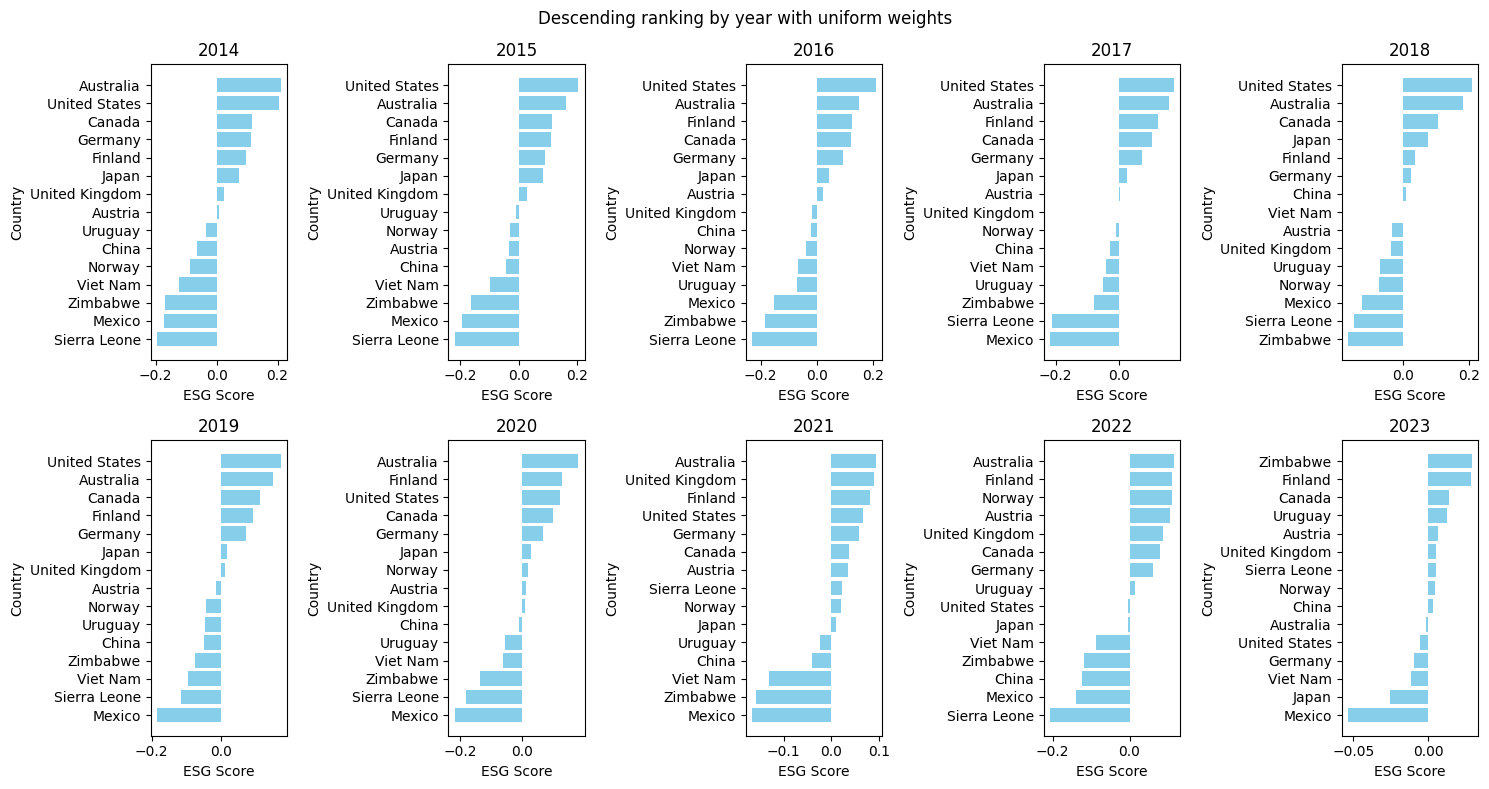

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
fig.suptitle("Descending ranking by year with uniform weights")
axes = axes.flatten()

# Loop through each year and create a subplot
for i, year in enumerate(years):
    # Sort by each year's values
    esg_sorted = esg_scores.sort_values(by=year, ascending=True)
    axes[i].barh(esg_sorted["Country"], esg_sorted[year], color="skyblue")
    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("ESG Score")
    axes[i].set_ylabel("Country")

plt.tight_layout()
plt.show()

## Conclusion

In case we consider **all weights uniform** some strange results are obtained, since in that case some developing country as Sierra Leone in 2021 comes to the first places being over the position of Norway and Austria, being very unlikely.
Furthermore many developed countries oscillates significantly between the first and middle positions in the ranking with score that becomes in some cases negative.
This may be due to 2 important factors:
- many datas may be missing for some countries that may not contribute significantly to the final score negatively.
- There may be some collinearity between the dataset since some quantity are highly correlated such as the emission of methane and tree cover loss or livestock .

In the end I hink the first version of weights is better since there is a clear division between developed, emerging and not developed countries since with those classes there should be more commitment to ESG goals.
The weigths influence significantly mainly by reducing in many case **the esg final linear score**.

In [ ]:
# I define vectors of expected returns and volatilities with the assigned values
mu = np.array([0.05, 0.055, 0.06, 0.04, 0.07, 0.065])
sigma = np.array([0.20, 0.22, 0.25, 0.18, 0.36, 0.35])
C = np.array([[1, 0.5, 0.3, 0.6, 0.4, 0.25],
              [0.5, 1, 0.3, 0.6, 0.3, 0.5],
              [0.3, 0.3, 1, 0.6, 0.7, 0.4],
              [0.6, 0.6, 0.6, 1, 0.3, 0.4],
              [0.4, 0.3, 0.7, 0.3, 1, 0.4],
              [0.25, 0.5, 0.4, 0.4, 0.4, 1]])

# I define the Covariance matrix
Sigma = np.outer(sigma, sigma) * C

def portfolio_variance(weights, Sigma):
    return np.dot(weights.T, np.dot(Sigma, weights))

def portfolio_return(weights, mu):
    return np.dot(weights, mu)

# Optimization function for each value of gamma
def mean_variance_optimization(mu, Sigma, gamma):
    constraints = ({'type': 'ineq', 'fun': lambda weights: 1- np.sum(np.abs(weights))})
    bounds = tuple((-1, 1) for i in range(len(mu)))

    def objective(weights):
        return 0.5 * weights.T@Sigma@weights - gamma * weights.T@mu

    initial_weights = np.ones(len(mu)) / len(mu)

    result = opt.minimize(objective, initial_weights, bounds=bounds, constraints=constraints)
    return result.x

gamma_values = [0, 0.1, 0.2, 0.5, 1]

# Solve for each gamma
optimal_weights = {}
for gamma in gamma_values:
    optimal_weights[gamma] = mean_variance_optimization(mu, Sigma, gamma)

# Display results
for gamma, weights in optimal_weights.items():
    print(f"Optimal weights for gamma = {gamma}: {weights}, sum: {np.sum(np.abs(weights)):.4f}")

Optimal weights for gamma = 0: [ 0.00538122 -0.00861074  0.01019536  0.0031797  -0.0001254  -0.00651875], sum: 0.0340
Optimal weights for gamma = 0.1: [ 0.0962487   0.08335732  0.0944724  -0.07912595 -0.01868253  0.0091087 ], sum: 0.3810
Optimal weights for gamma = 0.2: [ 0.19973915  0.15872998  0.20751555 -0.15964087 -0.05029638  0.02085565], sum: 0.7968
Optimal weights for gamma = 0.5: [ 0.33034097  0.2702479   0.30479553 -0.04718425 -0.00273643  0.04469492], sum: 1.0000
Optimal weights for gamma = 1: [2.95575809e-01 3.07946146e-01 2.48988660e-01 1.03175162e-04
 7.80426582e-02 6.93435521e-02], sum: 1.0000


In [ ]:
# Optimization function for each value of gamma
def mean_variance_optimization(mu, Sigma, gamma):
    constraints = ({'type': 'eq', 'fun': lambda weights: 1-np.sum(weights)})
    bounds = tuple((0, 1) for asset in range(len(mu))) #long-only

    def objective(weights):
        return 0.5 * weights.T@Sigma@weights - gamma * weights.T@mu

    initial_weights = np.ones(len(mu)) / len(mu)

    # Solve minimization problem
    result = opt.minimize(objective, initial_weights, bounds=bounds, constraints=constraints)
    return result.x

gamma_values = [0, 0.1, 0.2, 0.5, 1]

# Solve for each gamma
optimal_weights = {}
for gamma in gamma_values:
    optimal_weights[gamma] = mean_variance_optimization(mu, Sigma, gamma)

# Display results
for gamma, weights in optimal_weights.items():
    print(f"Optimal weights for gamma = {gamma}: {weights}, sum: {np.sum(weights):.4f}")

Optimal weights for gamma = 0: [3.29523453e-01 1.84047951e-01 1.63598602e-01 3.22829995e-01
 0.00000000e+00 9.81359458e-19], sum: 1.0000
Optimal weights for gamma = 0.1: [3.24933736e-01 2.11190454e-01 1.97307782e-01 2.61045203e-01
 1.40946282e-18 5.52282501e-03], sum: 1.0000
Optimal weights for gamma = 0.2: [0.37658213 0.24064409 0.23998743 0.12213811 0.         0.02064825], sum: 1.0000
Optimal weights for gamma = 0.5: [3.54985002e-01 2.84206653e-01 3.17379857e-01 2.40692882e-17
 1.12757026e-17 4.34284873e-02], sum: 1.0000
Optimal weights for gamma = 1: [2.60298148e-01 2.94005846e-01 3.18236954e-01 4.59701721e-17
 3.99536964e-02 8.75053560e-02], sum: 1.0000


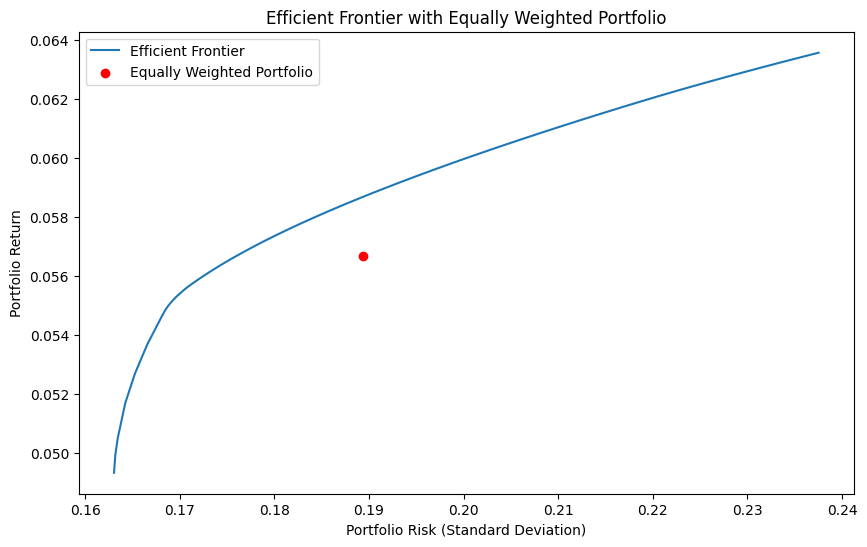

The equally weighted portfolio does not belong to the efficient frontier.


In [ ]:
def portfolio_variance(weights, Sigma):
    return np.dot(weights.T, np.dot(Sigma, weights))

# Compute the efficient frontier
frontier_returns = []
frontier_volatilities = []

for gamma in np.arange(0, 3, 0.05):
    optimal_weights = mean_variance_optimization(mu, Sigma, gamma)
    frontier_returns.append(portfolio_return(optimal_weights, mu))
    frontier_volatilities.append(np.sqrt(portfolio_variance(optimal_weights, Sigma)))

# Equally weighted portfolio
equal_weights = np.ones(len(mu)) / len(mu)
equal_return = portfolio_return(equal_weights, mu)
equal_risk = np.sqrt(portfolio_variance(equal_weights, Sigma))

# Plot the efficient frontier
plt.figure(figsize=(10,6))
plt.plot(frontier_volatilities, frontier_returns, label="Efficient Frontier")
plt.scatter(equal_risk, equal_return, color='red', label="Equally Weighted Portfolio")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Portfolio Return")
plt.title("Efficient Frontier with Equally Weighted Portfolio")
plt.legend()
plt.show()

# Output if equally weighted portfolio lies on the efficient frontier
min_diff = min([abs(equal_return - r) for r in frontier_returns])
if min_diff < 1e-6:  #small threshold to determine proximity
    print("The equally weighted portfolio belongs to the efficient frontier.")
else:
    print("The equally weighted portfolio does not belong to the efficient frontier.")

## CAPITAL MARKET LINE

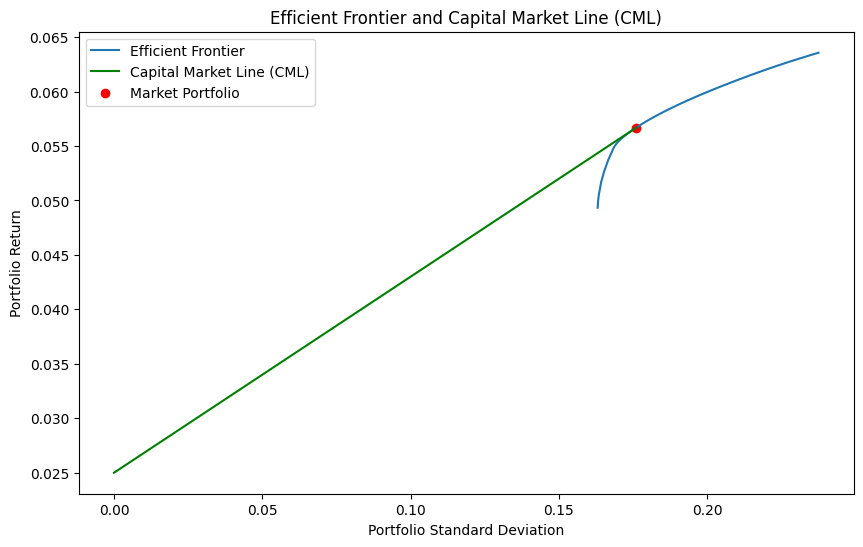

In [ ]:
# Risk-free rate
rf = 0.025

def portfolio_variance(weights, Sigma):
  return np.dot(weights.T, np.dot(Sigma, weights))

# Optimization function for the tangency portfolio (maximizing Sharpe ratio)
def tangency_portfolio(mu, Sigma, rf):
    def objective(weights):
        port_return = portfolio_return(weights, mu)
        port_vol = np.sqrt(portfolio_variance(weights, Sigma))
        return -(port_return - rf) / port_vol  #negative because we are maximizing

    initial_weights = np.ones(len(mu)) / len(mu)
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
    bounds = tuple((0, 1) for asset in range(len(mu)))  #Long-only portfolio

    # Solve the optimization problem
    result = opt.minimize(objective, initial_weights, bounds=bounds, constraints=constraints)
    return result.x

# Compute the market portfolio (tangency portfolio)
market_weights = tangency_portfolio(mu, Sigma, rf)
market_return = portfolio_return(market_weights, mu)
market_volatility = np.sqrt(portfolio_variance(market_weights, Sigma))

# Capital Market Line (CML)
cml_returns = np.linspace(rf, market_return, 100)
cml_volatilities = (cml_returns - rf) / (market_return - rf) * market_volatility

# Plot the efficient frontier and CML
plt.figure(figsize=(10, 6))
plt.plot(frontier_volatilities, frontier_returns, label="Efficient Frontier")
plt.plot(cml_volatilities, cml_returns, label="Capital Market Line (CML)", color='green')
plt.scatter(market_volatility, market_return, color='red', label="Market Portfolio")
plt.xlabel("Portfolio Standard Deviation")
plt.ylabel("Portfolio Return")
plt.title("Efficient Frontier and Capital Market Line (CML)")
plt.legend()
plt.show()

Optimal Portfolio Weights for ESG Investor:

ESG preference parameter φ = 0.05
γ = 0: [0.113 0.    0.    0.887 0.    0.   ], Expected Return: 0.0411, Variance: 0.0303, ESG Score: 0.8330
γ = 0.1: [0.1473 0.     0.     0.8527 0.     0.    ], Expected Return: 0.0415, Variance: 0.0299, ESG Score: 0.8279
γ = 0.2: [0.1866 0.     0.     0.8134 0.     0.    ], Expected Return: 0.0419, Variance: 0.0294, ESG Score: 0.8220
γ = 0.5: [0.2748 0.     0.     0.6799 0.0059 0.0395], Expected Return: 0.0439, Variance: 0.0283, ESG Score: 0.7950
γ = 1: [0.453  0.     0.2012 0.2219 0.     0.1238], Expected Return: 0.0517, Variance: 0.0288, ESG Score: 0.6858

ESG preference parameter φ = 0.1
γ = 0: [0. 0. 0. 1. 0. 0.], Expected Return: 0.0400, Variance: 0.0324, ESG Score: 0.8500
γ = 0.1: [0. 0. 0. 1. 0. 0.], Expected Return: 0.0400, Variance: 0.0324, ESG Score: 0.8500
γ = 0.2: [0. 0. 0. 1. 0. 0.], Expected Return: 0.0400, Variance: 0.0324, ESG Score: 0.8500
γ = 0.5: [0.0274 0.     0.     0.9726 0.     0.    

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

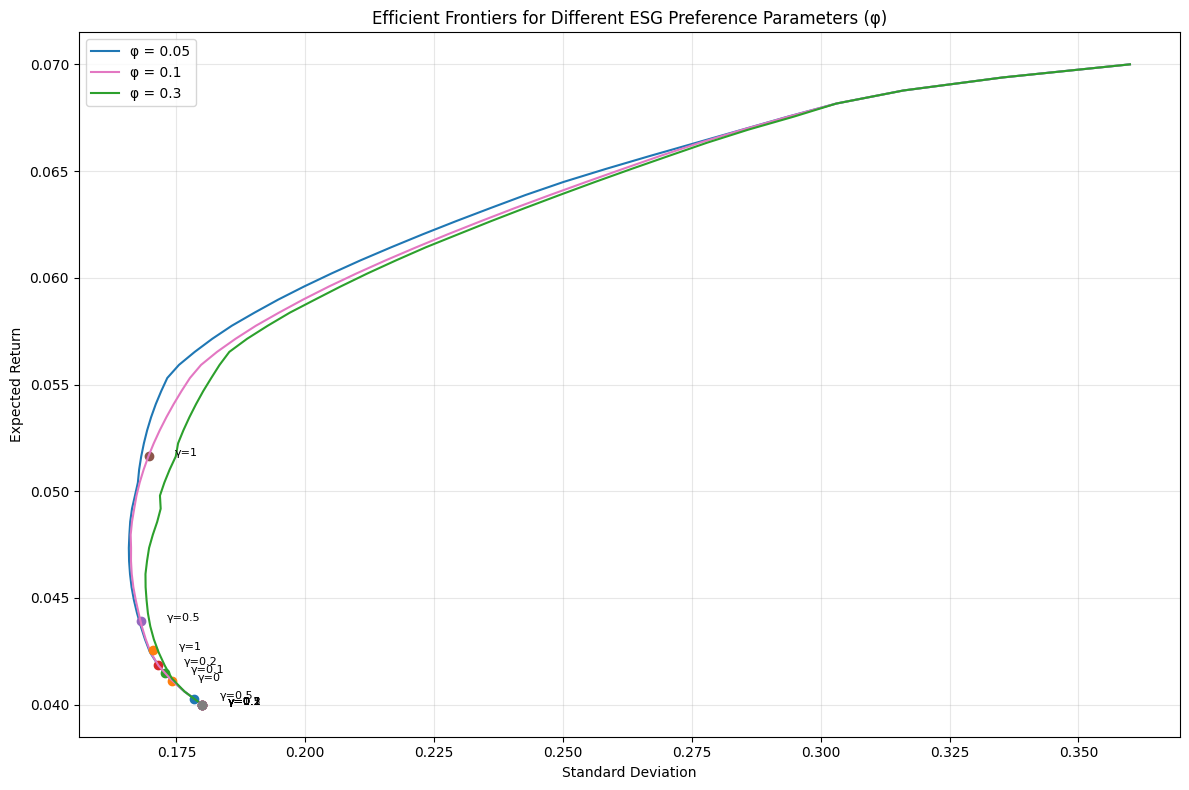

In [ ]:
### Optimal portfolio and efficient frontier for ESG investor

esg_scores = np.array([0.7, 0.4, 0.55, 0.85, 0.45, 0.56])

def portfolio_esg_score(weights, esg_scores):
    return np.dot(weights, esg_scores)

# Optimal portfolio
def mean_variance_esg_optimization(mu, Sigma, esg_scores, gamma, phi):
    n = len(mu)
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
    bounds = tuple((0, 1) for i in range(n))

    def objective(weights):
        return 0.5*portfolio_variance(weights, Sigma) - gamma*portfolio_return(weights, mu) - phi*portfolio_esg_score(weights, esg_scores) #U = w'μ - (γ/2)w'Σw + φw'e

    initial_weights = np.ones(n) / n

    result = opt.minimize(objective, initial_weights, bounds=bounds, constraints=constraints)
    return result.x

phi_values = [0.05, 0.1, 0.3]

optimal_weights_esg = {}
for phi in phi_values:
    optimal_weights_esg[phi] = {}
    for gamma in gamma_values:
        optimal_weights_esg[phi][gamma] = mean_variance_esg_optimization(mu, Sigma, esg_scores, gamma, phi)

# Efficient frontier
def efficient_frontier_points(mu, Sigma, esg_scores, phi, num_points=50):
    target_returns = np.linspace(min(mu), max(mu), num_points)
    frontier_variances = []
    frontier_weights = []
    frontier_esg_scores = []

    constraints = [
        {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
    ]
    bounds = tuple((0, 1) for i in range(len(mu)))

    for target in target_returns:
        constraints_return = constraints.copy()
        constraints_return.append(
            {'type': 'eq', 'fun': lambda weights: portfolio_return(weights, mu) - target}
        )

        def objective(weights):
            # For efficient frontier we minimize variance
            # If phi > 0, we include ESG preference
            var = portfolio_variance(weights, Sigma)
            esg = -phi * portfolio_esg_score(weights, esg_scores) if phi > 0 else 0
            return var + esg

        initial_weights = np.ones(len(mu)) / len(mu)
        try:
            result = opt.minimize(objective, initial_weights, bounds=bounds, constraints=constraints_return)
            if result.success:
                frontier_weights.append(result.x)
                frontier_variances.append(portfolio_variance(result.x, Sigma))
                frontier_esg_scores.append(portfolio_esg_score(result.x, esg_scores))
            else:
                continue
        except:
            continue

    return target_returns[:len(frontier_variances)], frontier_variances, frontier_weights, frontier_esg_scores

# Calculate efficient frontiers for different phi values
efficient_frontiers = {}
for phi in phi_values:
    returns, variances, weights, esg_scores_pf = efficient_frontier_points(mu, Sigma, esg_scores, phi)
    efficient_frontiers[phi] = {
        'returns': returns,
        'variances': variances,
        'weights': weights,
        'esg_scores': esg_scores_pf
    }

# Print results
def print_results():
    # Print optimal portfolio weights
    print("Optimal Portfolio Weights for ESG Investor:")
    for phi in phi_values:
        print(f"\nESG preference parameter φ = {phi}")
        for gamma in gamma_values:
            weights = optimal_weights_esg[phi][gamma]
            print(f"γ = {gamma}: {np.round(weights, 4)}, Expected Return: {portfolio_return(weights, mu):.4f}, Variance: {portfolio_variance(weights, Sigma):.4f}, ESG Score: {portfolio_esg_score(weights, esg_scores):.4f}")

    # Plot efficient frontiers
    plt.figure(figsize=(12, 8))

    for phi in phi_values:
        frontier_data = efficient_frontiers[phi]
        std_devs = np.sqrt(frontier_data['variances'])
        plt.plot(std_devs, frontier_data['returns'], '-', label=f'φ = {phi}')

        # Plot optimal portfolios
        for gamma in gamma_values:
            weights = optimal_weights_esg[phi][gamma]
            std_dev = np.sqrt(portfolio_variance(weights, Sigma))
            ret = portfolio_return(weights, mu)
            plt.plot(std_dev, ret, 'o', markersize=6)
            plt.text(std_dev+0.005, ret, f'γ={gamma}', fontsize=8)

    plt.xlabel('Standard Deviation')
    plt.ylabel('Expected Return')
    plt.title('Efficient Frontiers for Different ESG Preference Parameters (φ)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return plt

print_results()


In [ ]:
def market_equilibrium(mu, Sigma, esg_scores, omega_esg, gamma_esg, phi, gamma_M):
    # Optimal portfolio for ESG investor
    weights_esg = mean_variance_esg_optimization(mu, Sigma, esg_scores, gamma_esg, phi)

    # Optimal portfolio for non-ESG investor (phi = 0)
    weights_non_esg = mean_variance_esg_optimization(mu, Sigma, esg_scores, gamma_M, 0)

    # Market portfolio (weighted average of the two investors)
    market_portfolio = omega_esg * weights_esg + (1 - omega_esg) * weights_non_esg

    # Asset risk premia
    portfolio_variance = np.dot(market_portfolio.T, np.dot(Sigma, market_portfolio))
    risk_premia = mu - gamma_M * portfolio_variance

    return market_portfolio, risk_premia, weights_esg, weights_non_esg

# Calculate market portfolios for different parameter combinations
omega_values = [0.3, 0.5, 0.8]
gamma_esg_values = [0.2, 0.5, 0.8]
phi_values = [0.05, 0.1, 0.3]
gamma_M = 0.5

equilibrium_results = {}
for omega in omega_values:
    equilibrium_results[omega] = {}
    for gamma_esg in gamma_esg_values:
        equilibrium_results[omega][gamma_esg] = {}
        for phi in phi_values:
            market_portfolio, risk_premia, weights_esg, weights_non_esg = market_equilibrium(
                mu, Sigma, esg_scores, omega, gamma_esg, phi, gamma_M)

            equilibrium_results[omega][gamma_esg][phi] = {
                'market_portfolio': market_portfolio,
                'risk_premia': risk_premia,
                'weights_esg': weights_esg,
                'weights_non_esg': weights_non_esg
            }

# Display market equilibrium results
def print_market_results():
    print("\nMarket Equilibrium Results:")
    omega, gamma_esg, phi = 0.5, 0.5, 0.1
    result = equilibrium_results[omega][gamma_esg][phi]

    print(f"Parameters: ω_esg = {omega}, γ_esg = {gamma_esg}, φ = {phi}, γ_M = {gamma_M}")
    print(f"Market Portfolio: {np.round(result['market_portfolio'], 4)}")
    print(f"Expected Return: {portfolio_return(result['market_portfolio'], mu):.4f}")
    print(f"Variance: {portfolio_variance(result['market_portfolio'], Sigma):.4f}")
    print(f"ESG Score: {portfolio_esg_score(result['market_portfolio'], esg_scores):.4f}")
    print(f"Risk Premia: {np.round(result['risk_premia'], 4)}")

# Execute the results printing
print_market_results()



Market Equilibrium Results:
Parameters: ω_esg = 0.5, γ_esg = 0.5, φ = 0.1, γ_M = 0.5
Market Portfolio: [0.1912 0.1421 0.1587 0.4863 0.     0.0217]
Expected Return: 0.0478
Variance: 0.0272
ESG Score: 0.7035
Risk Premia: [0.0364 0.0414 0.0464 0.0264 0.0564 0.0514]


In [ ]:
price_file_path = "SP500_price_data.csv"
esg_file_path = "sp500_esg_data.csv"

# Load the full Price dataset
price_df = pd.read_csv(price_file_path, parse_dates=["Date"], index_col="Date")
print("Full Price Dataset:")
display(price_df)

# Define the selected tickers list
selected_tickers = [
    'GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN',
    'ADI', 'MSI', 'CRM', 'COST', 'PEP', 'AMAT', 'NOW', 'ADSK',
    'NXPI', 'INTU', 'SNPS', 'MU'
]

# Subset the Price dataset for the selected tickers
price_subset = price_df[selected_tickers]
print("Price Dataset for Selected Tickers:")
display(price_subset)

# Load the full ESG dataset
esg_df = pd.read_csv(esg_file_path)
print("Full ESG Dataset:")
display(esg_df)

# Subset the ESG dataset for the selected tickers (assuming the column 'Symbol' holds the ticker)
esg_subset = esg_df[esg_df['Symbol'].isin(selected_tickers)]
print("ESG Dataset for Selected Tickers:")
display(esg_subset)

Full Price Dataset:


,ADI,ADSK,AKAM,AMAT,CDW,COST,CRM,FTNT,GLW,INTU,MSI,MU,NOW,NXPI,PEP,ROP,SNPS,TEL,TER,VRSN
Date,,,,,,,,,,,,,,,,,,,,
2010-01-04,21.897829,25.670000,25.920000,11.027137,NaN,42.104370,18.480457,1.800000,13.277516,27.143719,25.186501,10.586311,NaN,NaN,37.962635,47.718288,22.440001,18.403158,10.088493,20.826298
2010-01-05,21.863255,25.280001,26.690001,10.942315,NaN,41.976826,18.401419,1.839000,13.325032,27.143719,24.838881,10.898534,NaN,NaN,38.421352,47.109753,22.250000,18.131113,10.125312,21.045168
2010-01-06,21.821770,25.340000,26.469999,10.919183,NaN,42.522530,18.369308,1.941000,13.155326,26.764885,25.186501,10.947318,NaN,NaN,38.037029,47.560177,22.209999,18.498743,10.033263,20.817881
2010-01-07,21.648903,25.480000,26.480000,10.803514,NaN,42.316994,18.287800,1.945000,13.284306,26.676786,25.692123,10.576555,NaN,NaN,37.795246,47.378212,22.150000,18.153173,10.088493,20.531666
2010-01-08,21.773365,26.260000,26.480000,11.219925,NaN,42.012245,18.314970,2.011000,13.501522,27.381594,24.522863,10.830236,NaN,NaN,37.671257,47.714878,22.309999,18.381096,10.198954,20.691608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,277.559998,298.209991,88.820000,260.779999,138.710007,870.670532,265.260010,81.180000,89.660004,673.589417,376.480011,286.564240,152.589996,225.259995,143.740005,450.257629,475.750000,231.899994,198.529999,245.750000
2025-12-26,276.839996,300.709991,88.419998,261.899994,139.710007,872.158447,266.079987,81.559998,89.570000,675.306213,377.040009,284.675018,153.889999,222.869995,143.779999,449.908356,477.140015,232.490005,198.899994,246.320007
2025-12-29,275.630005,301.230011,88.239998,263.049988,138.610001,866.656067,266.230011,80.820000,89.000000,672.910706,377.279999,294.369995,154.580002,220.460007,144.240005,449.918335,478.970001,231.800003,197.360001,245.149994


Price Dataset for Selected Tickers:


,GLW,TER,TEL,CDW,ROP,AKAM,FTNT,VRSN,ADI,MSI,CRM,COST,PEP,AMAT,NOW,ADSK,NXPI,INTU,SNPS,MU
Date,,,,,,,,,,,,,,,,,,,,
2010-01-04,13.277516,10.088493,18.403158,NaN,47.718288,25.920000,1.800000,20.826298,21.897829,25.186501,18.480457,42.104370,37.962635,11.027137,NaN,25.670000,NaN,27.143719,22.440001,10.586311
2010-01-05,13.325032,10.125312,18.131113,NaN,47.109753,26.690001,1.839000,21.045168,21.863255,24.838881,18.401419,41.976826,38.421352,10.942315,NaN,25.280001,NaN,27.143719,22.250000,10.898534
2010-01-06,13.155326,10.033263,18.498743,NaN,47.560177,26.469999,1.941000,20.817881,21.821770,25.186501,18.369308,42.522530,38.037029,10.919183,NaN,25.340000,NaN,26.764885,22.209999,10.947318
2010-01-07,13.284306,10.088493,18.153173,NaN,47.378212,26.480000,1.945000,20.531666,21.648903,25.692123,18.287800,42.316994,37.795246,10.803514,NaN,25.480000,NaN,26.676786,22.150000,10.576555
2010-01-08,13.501522,10.198954,18.381096,NaN,47.714878,26.480000,2.011000,20.691608,21.773365,24.522863,18.314970,42.012245,37.671257,11.219925,NaN,26.260000,NaN,27.381594,22.309999,10.830236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,89.660004,198.529999,231.899994,138.710007,450.257629,88.820000,81.180000,245.750000,277.559998,376.480011,265.260010,870.670532,143.740005,260.779999,152.589996,298.209991,225.259995,673.589417,475.750000,286.564240
2025-12-26,89.570000,198.899994,232.490005,139.710007,449.908356,88.419998,81.559998,246.320007,276.839996,377.040009,266.079987,872.158447,143.779999,261.899994,153.889999,300.709991,222.869995,675.306213,477.140015,284.675018
2025-12-29,89.000000,197.360001,231.800003,138.610001,449.918335,88.239998,80.820000,245.149994,275.630005,377.279999,266.230011,866.656067,144.240005,263.049988,154.580002,301.230011,220.460007,672.910706,478.970001,294.369995


Full ESG Dataset:


,Symbol,Full Name,GICS Sector,GICS Sub-Industry,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,percentile,ratingYear,ratingMonth,marketCap,beta,overallRisk
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,1.12,6.42,6.10,13.64,2.0,7.98,2023.0,9.0,39751831552,1.054,8
1,AAL,American Airlines Group,Industrials,Passenger Airlines,9.94,11.65,4.76,26.35,2.0,54.48,2023.0,9.0,7335383552,1.433,10
2,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",0.46,7.39,9.37,17.22,3.0,17.82,2023.0,9.0,3296096681984,1.240,1
3,ABBV,AbbVie,Health Care,Biotechnology,2.38,17.19,10.36,29.93,3.0,68.62,2023.0,9.0,341698445312,0.619,6
4,ABT,Abbott Laboratories,Health Care,Health Care Equipment,2.27,14.24,8.33,24.83,3.0,48.27,2023.0,9.0,205534380032,0.722,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,XOM,ExxonMobil,Energy,Integrated Oil & Gas,23.11,10.01,8.48,41.60,3.0,93.17,2023.0,9.0,507282325504,0.878,7
422,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,4.27,8.66,5.19,18.13,1.0,20.92,2023.0,9.0,32338771968,1.037,3
423,YUM,Yum! Brands,Consumer Discretionary,Restaurants,4.53,11.45,4.12,20.10,2.0,28.34,2023.0,9.0,37833572352,1.081,2
424,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,3.60,14.52,7.89,26.02,2.0,53.22,2023.0,9.0,21635987456,1.026,2


ESG Dataset for Selected Tickers:


,Symbol,Full Name,GICS Sector,GICS Sub-Industry,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,percentile,ratingYear,ratingMonth,marketCap,beta,overallRisk
8,ADI,Analog Devices,Information Technology,Semiconductors,9.27,6.68,6.98,22.92,1.0,39.70,2023.0,9.0,111884697600,1.073,9
11,ADSK,Autodesk,Information Technology,Application Software,3.68,8.19,4.89,16.76,0.0,16.44,2023.0,9.0,57698152448,1.476,2
19,AKAM,Akamai Technologies,Information Technology,Internet Services & Infrastructure,3.00,7.09,6.93,17.01,1.0,17.19,2023.0,9.0,15044968448,0.676,3
23,AMAT,Applied Materials,Information Technology,Semiconductor Materials & Equipment,4.49,2.97,5.28,12.74,1.0,6.15,2023.0,9.0,155474345984,1.541,1
75,CDW,CDW,Information Technology,Technology Distributors,2.48,3.21,3.52,9.21,0.0,2.18,2023.0,9.0,29830193152,1.033,3
97,COST,Costco,Consumer Staples,Consumer Staples Merchandise Retail,6.52,11.22,5.55,23.29,3.0,41.46,2023.0,9.0,402490195968,0.788,2
101,CRM,Salesforce,Information Technology,Application Software,2.01,7.48,5.39,14.88,1.0,10.87,2023.0,9.0,243961643008,1.297,9
166,FTNT,Fortinet,Information Technology,Systems Software,2.50,10.03,6.37,18.90,1.0,23.77,2023.0,9.0,58393071616,0.998,6
174,GLW,Corning Inc.,Information Technology,Electronic Components,5.53,4.81,6.13,16.48,2.0,15.51,2023.0,9.0,37051850752,1.036,7
207,INTU,Intuit,Information Technology,Application Software,0.97,10.70,4.73,16.41,2.0,15.32,2023.0,9.0,181138964480,1.243,2




Markowitz Mean-Variance Portfolio Model on Risk and Return


Using data from 2023-01-03 00:00:00 to 2023-12-29 00:00:00 (Total days: 360)


Tickers used for analysis: ['GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN', 'ADI', 'MSI', 'CRM', 'AMAT', 'NOW', 'ADSK', 'NXPI', 'INTU', 'SNPS', 'MU']




Annualized return of the optimized portfolio: 79.00%
Annualized volatility of the optimized portfolio: 23.07%
Sharpe Ratio: 3.38




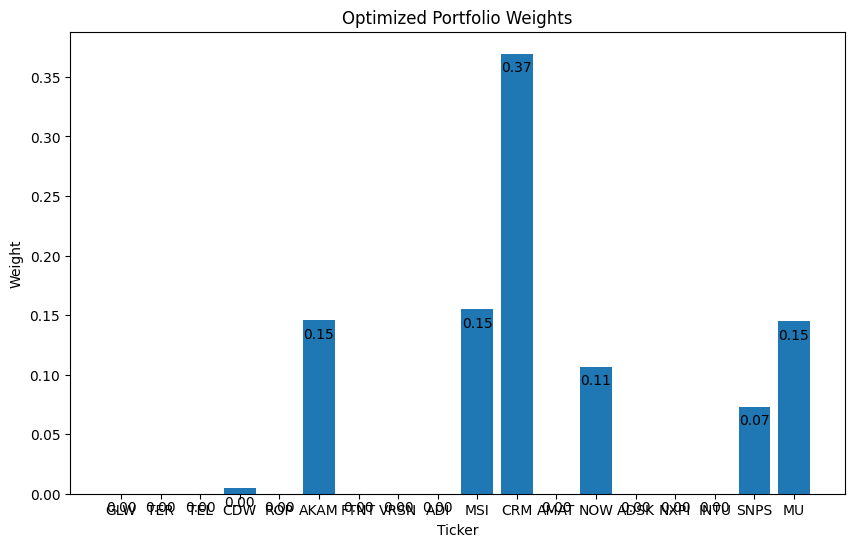



Optimized Weights:
GLW: 0.00
TER: 0.00
TEL: 0.00
CDW: 0.00
ROP: 0.00
AKAM: 0.15
FTNT: 0.00
VRSN: 0.00
ADI: 0.00
MSI: 0.15
CRM: 0.37
AMAT: 0.00
NOW: 0.11
ADSK: 0.00
NXPI: 0.00
INTU: 0.00
SNPS: 0.07
MU: 0.15




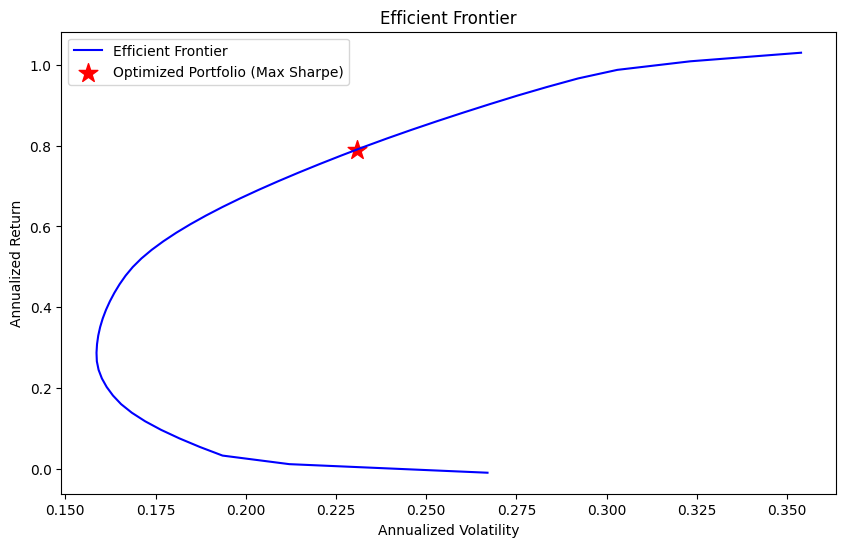

In [ ]:
separator = "\n" + "="*50 + "\n"

print(separator)
print("Markowitz Mean-Variance Portfolio Model on Risk and Return")
print(separator)

#path
adj_close = pd.read_csv(
    price_file_path,
    parse_dates=["Date"],
    index_col="Date"
)
adj_close.sort_index(inplace=True)

# Filter data for 2023 only
adj_close = adj_close.loc["2023-01-01":"2023-12-31"]

# Automatically determine the full date range from the dataset
start_date = adj_close.index.min()
end_date = adj_close.index.max()
num_days = (end_date - start_date).days

print(f"Using data from {start_date} to {end_date} (Total days: {num_days})")
print(separator)


selected_tickers = ['GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN', 'ADI',
                      'MSI', 'CRM', 'ANSS', 'JNPR', 'AMAT', 'NOW', 'ADSK', 'NXPI',
                      'INTU', 'SNPS', 'MU']

# Check which tickers are available in the price dataset
missing_tickers = [t for t in selected_tickers if t not in adj_close.columns]
if missing_tickers:
    print(f"WARNING: The following tickers are not in the price dataset: {missing_tickers}")

tickers = [t for t in selected_tickers if t in adj_close.columns]
if len(tickers) == 0:
    raise ValueError("No tickers from the selected list were found in the price dataset.")

adj_close = adj_close[tickers]

print(f"Tickers used for analysis: {tickers}")
print(separator)

returns = adj_close.pct_change().dropna()


#Define Functions for Portfolio Performance and Optimization

def portfolio_performance(weights, returns, days):
    """
    Calculate the annualized portfolio return and volatility.
    """
    mean_daily_return = returns.mean()
    port_return = np.sum(mean_daily_return * weights) * days
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * days, weights)))
    return port_return, port_vol

def negative_sharpe_ratio(weights, returns, days, risk_free_rate=0.0):
    """
    Returns the negative Sharpe ratio (to be minimized).
    """
    ret, vol = portfolio_performance(weights, returns, days)
    sharpe = (ret - risk_free_rate) / vol
    return -sharpe

def optimize_portfolio(returns, days, risk_free_rate=0.0):
    """
    Optimize portfolio weights to maximize the Sharpe ratio.
    """
    num_assets = len(returns.columns)
    initial_weights = np.array([1.0 / num_assets] * num_assets)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))

    result = minimize(
        fun=negative_sharpe_ratio,
        x0=initial_weights,
        args=(returns, days, risk_free_rate),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result


#Optimize the Portfolio (Maximizing Sharpe Ratio)

risk_free_rate = 0.01
opt_result = optimize_portfolio(returns, num_days, risk_free_rate)
optimized_weights = opt_result.x

port_return, port_vol = portfolio_performance(optimized_weights, returns, num_days)

print(separator)
print(f"Annualized return of the optimized portfolio: {port_return*100:.2f}%")
print(f"Annualized volatility of the optimized portfolio: {port_vol*100:.2f}%")
print(f"Sharpe Ratio: {(port_return - risk_free_rate) / port_vol:.2f}")
print(separator)


#Plot Optimized Weights

plt.figure(figsize=(10,6))
plt.bar(tickers, optimized_weights)
plt.xlabel("Ticker")
plt.ylabel("Weight")
plt.title("Optimized Portfolio Weights")
for i, weight in enumerate(optimized_weights):
    plt.annotate(f"{weight:.2f}", xy=(i, weight), xycoords='data',
                 xytext=(0, -5), textcoords='offset points', ha='center', va='top', fontsize=10)
plt.show()

print(separator)
print("Optimized Weights:")
for ticker, weight in zip(tickers, optimized_weights):
    print(f"{ticker}: {weight:.2f}")
print(separator)

def minimize_variance_given_target(target, returns, days):
    num_assets = len(returns.columns)
    mean_daily_return = returns.mean()

    def objective(weights):
        return np.dot(weights.T, np.dot(returns.cov() * days, weights))

    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(mean_daily_return * x) * days - target}
    ]
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = np.array([1/num_assets] * num_assets)

    result = minimize(
        fun=objective,
        x0=initial_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result

mean_daily_return = returns.mean()
min_target = np.min(mean_daily_return) * num_days
max_target = np.max(mean_daily_return) * num_days

target_returns = np.linspace(min_target, max_target, 50)
efficient_vols = []
efficient_rets = []

for target in target_returns:
    res = minimize_variance_given_target(target, returns, num_days)
    if res.success:
        w = res.x
        ret, vol = portfolio_performance(w, returns, num_days)
        efficient_rets.append(ret)
        efficient_vols.append(vol)
    else:
        efficient_rets.append(np.nan)
        efficient_vols.append(np.nan)

plt.figure(figsize=(10,6))
plt.plot(efficient_vols, efficient_rets, 'b-', label='Efficient Frontier')
plt.scatter(port_vol, port_return, color='red', marker='*', s=200, label='Optimized Portfolio (Max Sharpe)')
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier")
plt.legend()
plt.show()

In [ ]:
TRADING_DAYS = 252  # trading days per year
ESG_THRESHOLD = 0.5  # Soglia per il punteggio ESG normalizzato

#path
price_df = pd.read_csv(price_file_path, parse_dates=["Date"], index_col="Date")
price_df.sort_index(inplace=True)

price_df = price_df.loc["2024-01-01":"2024-12-31"]

start_date = price_df.index.min()
end_date = price_df.index.max()
num_days = (end_date - start_date).days
print(f"Using price data from {start_date.date()} to {end_date.date()} (Total days: {num_days})")

#path
df_esg = pd.read_csv(esg_file_path)

fixed_tickers = ['GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN',
                 'ADI', 'MSI', 'CRM', 'COST', 'PEP', 'AMAT', 'NOW', 'ADSK',
                 'NXPI', 'INTU', 'SNPS', 'MU']

df_esg_fixed = df_esg[df_esg['Symbol'].isin(fixed_tickers)].copy()
if df_esg_fixed.empty:
    raise ValueError('None of the fixed tickers were found in the ESG dataset.')

df_esg_fixed.sort_values('Symbol', inplace=True)
df_esg_fixed.reset_index(drop=True, inplace=True)

min_esg = df_esg_fixed['totalEsg'].min()
max_esg = df_esg_fixed['totalEsg'].max()
df_esg_fixed['normalized_ESG'] = (df_esg_fixed['totalEsg'] - min_esg) / (max_esg - min_esg)

print("Fixed ESG Data (with normalized ESG scores):")
display(df_esg_fixed[['Symbol', 'totalEsg', 'normalized_ESG']])

df_esg_exclusion = df_esg_fixed[df_esg_fixed['normalized_ESG'] >= ESG_THRESHOLD]
print(f"Stocks that pass ESG exclusion (normalized_ESG >= {ESG_THRESHOLD}):")
display(df_esg_exclusion[['Symbol', 'normalized_ESG']])

# Crea la lista dei ticker che superano il filtro ESG e che sono presenti nei dati di prezzo
selected_tickers = df_esg_exclusion['Symbol'].tolist()
selected_tickers = [t for t in selected_tickers if t in price_df.columns]
print("Selected tickers after ESG exclusion:", selected_tickers)

price_df = price_df[selected_tickers]

returns_daily = price_df.pct_change().dropna()
mu_annual = returns_daily.mean() * TRADING_DAYS
Sigma_annual = returns_daily.cov() * TRADING_DAYS

print("\nAnnualized Expected Returns (historical) for ESG-exclusion portfolio:")
print(mu_annual)
print("\nAnnualized Covariance Matrix for ESG-exclusion portfolio:")
print(Sigma_annual)

# Construct an Equally Weighted Portfolio (ESG-Exclusion)
num_assets = len(selected_tickers)
w_equal = np.ones(num_assets) / num_assets  # Peso uguale per ogni asset

df_weights_equal = pd.DataFrame({'Ticker': selected_tickers, 'Equal_Weight': w_equal})
print("-" * 80)
print("Equal-Weighted ESG-Exclusion Portfolio:")
display(df_weights_equal)


# 7. Evaluate Portfolio Performance

def portfolio_performance(weights, mu, Sigma):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    return port_return, port_vol

port_return_equal, port_vol_equal = portfolio_performance(w_equal, mu_annual, Sigma_annual)
print(f"Equal-Weighted Portfolio Annualized Return: {port_return_equal*100:.2f}%")
print(f"Equal-Weighted Portfolio Annualized Volatility: {port_vol_equal*100:.2f}%")
print(f"Equal-Weighted Portfolio Sharpe Ratio: {(port_return_equal/port_vol_equal):.2f}")

Using price data from 2024-01-02 to 2024-12-31 (Total days: 364)
Fixed ESG Data (with normalized ESG scores):


,Symbol,totalEsg,normalized_ESG
0,ADI,22.92,0.973722
1,ADSK,16.76,0.536222
2,AKAM,17.01,0.553977
3,AMAT,12.74,0.250710
4,CDW,9.21,0.000000
5,COST,23.29,1.000000
6,CRM,14.88,0.402699
7,FTNT,18.90,0.688210
8,GLW,16.48,0.516335
9,INTU,16.41,0.511364


Stocks that pass ESG exclusion (normalized_ESG >= 0.5):


,Symbol,normalized_ESG
0,ADI,0.973722
1,ADSK,0.536222
2,AKAM,0.553977
5,COST,1.000000
7,FTNT,0.688210
8,GLW,0.516335
9,INTU,0.511364
11,MU,0.637074
12,NOW,0.524148
13,NXPI,0.754972


Selected tickers after ESG exclusion: ['ADI', 'ADSK', 'AKAM', 'COST', 'FTNT', 'GLW', 'INTU', 'MU', 'NOW', 'NXPI', 'PEP', 'ROP', 'TER', 'VRSN']

Annualized Expected Returns (historical) for ESG-exclusion portfolio:
ADI     0.159843
ADSK    0.270289
AKAM   -0.155311
COST    0.367562
FTNT    0.565615
GLW     0.509940
INTU    0.085857
MU      0.159013
NOW     0.492380
NXPI    0.017167
PEP    -0.084137
ROP    -0.006345
TER     0.287353
VRSN    0.044619
dtype: float64

Annualized Covariance Matrix for ESG-exclusion portfolio:
           ADI      ADSK      AKAM      COST      FTNT       GLW      INTU  \
ADI   0.099883  0.035241  0.026079  0.019776  0.009758  0.032893  0.033535   
ADSK  0.035241  0.072148  0.021204  0.018017  0.022811  0.019643  0.037248   
AKAM  0.026079  0.021204  0.089385  0.003414  0.006647  0.013089  0.012778   
COST  0.019776  0.018017  0.003414  0.035392  0.010907  0.010976  0.016505   
FTNT  0.009758  0.022811  0.006647  0.010907  0.152467  0.007575  0.029943   
GLW   

,Ticker,Equal_Weight
0,ADI,0.071429
1,ADSK,0.071429
2,AKAM,0.071429
3,COST,0.071429
4,FTNT,0.071429
5,GLW,0.071429
6,INTU,0.071429
7,MU,0.071429
8,NOW,0.071429
9,NXPI,0.071429


Equal-Weighted Portfolio Annualized Return: 19.38%
Equal-Weighted Portfolio Annualized Volatility: 17.32%
Equal-Weighted Portfolio Sharpe Ratio: 1.12


Using price data from 2024-01-02 to 2024-12-31 (Total days: 364)
Fixed ESG Data (with normalized ESG scores):


,Symbol,totalEsg,normalized_ESG
0,ADI,22.92,1.000000
1,ADSK,16.76,0.550693
2,AKAM,17.01,0.568928
3,AMAT,12.74,0.257476
4,ANSS,15.89,0.487236
5,CDW,9.21,0.000000
6,CRM,14.88,0.413567
7,FTNT,18.90,0.706783
8,GLW,16.48,0.530270
9,INTU,16.41,0.525164


Tickers used for analysis: ['GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN', 'ADI', 'MSI', 'CRM', 'AMAT', 'NOW', 'ADSK', 'NXPI', 'INTU', 'SNPS', 'MU']

Annualized Expected Returns (historical):
GLW     0.509940
TER     0.287353
TEL     0.067419
CDW    -0.188980
ROP    -0.006345
AKAM   -0.155311
FTNT    0.565615
VRSN    0.044619
ADI     0.159843
MSI     0.420984
CRM     0.339916
AMAT    0.150002
NOW     0.492380
ADSK    0.270289
NXPI    0.017167
INTU    0.085857
SNPS    0.039918
MU      0.159013
dtype: float64

Annualized Covariance Matrix:
           GLW       TER       TEL       CDW       ROP      AKAM      FTNT  \
GLW   0.071278  0.048579  0.024873  0.022702  0.011597  0.013089  0.007575   
TER   0.048579  0.195163  0.048052  0.048600  0.027051  0.027515  0.012994   
TEL   0.024873  0.048052  0.043109  0.029293  0.013462  0.018313  0.011298   
CDW   0.022702  0.048600  0.029293  0.073837  0.016300  0.022287  0.013265   
ROP   0.011597  0.027051  0.013462  0.016300  0.031723

,Ticker,Optimized_Weight
0,GLW,2.589148e-01
1,TER,0.000000e+00
2,TEL,3.420779e-18
3,CDW,0.000000e+00
4,ROP,0.000000e+00
5,AKAM,0.000000e+00
6,FTNT,9.959702e-02
7,VRSN,1.735673e-15
8,ADI,0.000000e+00
9,MSI,4.989195e-01


--------------------------------------------------------------------------------
Optimized Portfolio Annualized Return: 46.86%
Optimized Portfolio Annualized Volatility: 15.18%
Optimized Portfolio Sharpe Ratio (assuming risk-free rate = 0): 3.09
--------------------------------------------------------------------------------


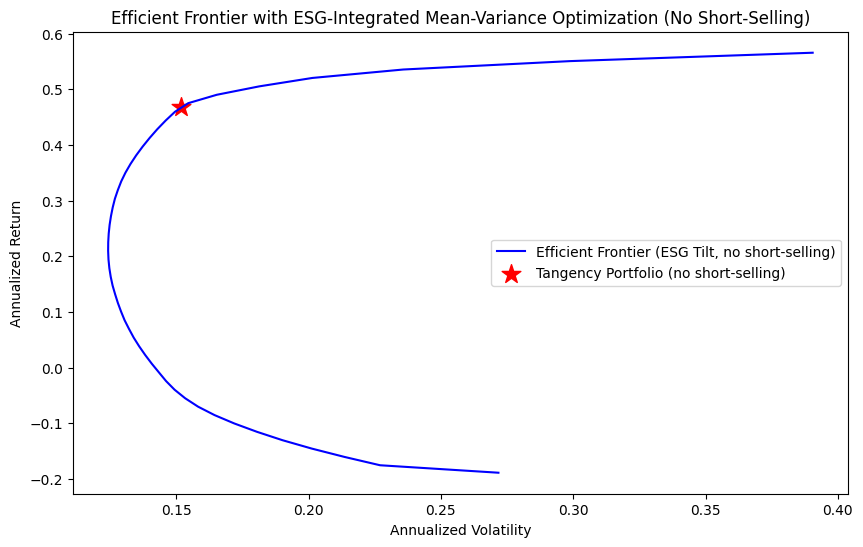

Sum of Optimized Portfolio Weights (should be 1): 1.0000000000000087


In [ ]:
TRADING_DAYS = 252
zeta = 0.01

#path
price_df = pd.read_csv(price_file_path, parse_dates=["Date"], index_col="Date")
price_df.sort_index(inplace=True)


price_df = price_df.loc["2024-01-01":"2024-12-31"]

start_date = price_df.index.min()
end_date = price_df.index.max()
num_days = (end_date - start_date).days
print(f"Using price data from {start_date.date()} to {end_date.date()} (Total days: {num_days})")

#path
df_esg = pd.read_csv(esg_file_path)

fixed_tickers = ['GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN',
                 'ADI', 'MSI', 'CRM', 'ANSS', 'JNPR', 'AMAT', 'NOW', 'ADSK',
                 'NXPI', 'INTU', 'SNPS', 'MU']

df_esg_fixed = df_esg[df_esg['Symbol'].isin(fixed_tickers)].copy()

df_esg_fixed.sort_values('Symbol', inplace=True)
df_esg_fixed.reset_index(drop=True, inplace=True)

min_esg = df_esg_fixed['totalEsg'].min()
max_esg = df_esg_fixed['totalEsg'].max()
df_esg_fixed['normalized_ESG'] = (df_esg_fixed['totalEsg'] - min_esg) / (max_esg - min_esg)

print("Fixed ESG Data (with normalized ESG scores):")
display(df_esg_fixed[['Symbol', 'totalEsg', 'normalized_ESG']])

missing_in_price = [t for t in fixed_tickers if t not in price_df.columns]

tickers = [t for t in fixed_tickers if t in price_df.columns]

price_df = price_df[tickers]
print(f"Tickers used for analysis: {tickers}")

returns_daily = price_df.pct_change().dropna()
mu_annual = returns_daily.mean() * TRADING_DAYS
Sigma_annual = returns_daily.cov() * TRADING_DAYS

print("\nAnnualized Expected Returns (historical):")
print(mu_annual)
print("\nAnnualized Covariance Matrix:")
print(Sigma_annual)

# Merge ESG Scores with Expected Returns
df_esg_fixed.set_index('Symbol', inplace=True)
normalized_ESG = df_esg_fixed.loc[tickers, 'normalized_ESG']


# Compute Modified Expected Returns (ESG)

mu_mod = mu_annual + zeta * normalized_ESG
print("\nModified Annualized Expected Returns (with ESG):")
print(mu_mod)

def neg_sharpe_ratio(w, mu, Sigma):
    ret = np.dot(w, mu)
    vol = np.sqrt(np.dot(w, np.dot(Sigma, w)))
    return -ret / vol

# Constraint
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(len(tickers)))
initial_weights = np.array([1.0 / len(tickers)] * len(tickers))

res = minimize(neg_sharpe_ratio, initial_weights, args=(mu_mod.values, Sigma_annual),
               method='SLSQP', bounds=bounds, constraints=constraints)

if res.success:
    w_tan_noshort = res.x
else:
    raise ValueError("Optimization for tangency portfolio with no short-selling failed.")

df_weights_noshort = pd.DataFrame({'Ticker': tickers, 'Optimized_Weight': w_tan_noshort})
print("-" * 80)
print("Optimized Portfolio Weights (ESG-integrated Mean-Variance Optimization with no short-selling):")
display(df_weights_noshort)

def portfolio_performance(weights, mu, Sigma):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    return port_return, port_vol

port_return_noshort, port_vol_noshort = portfolio_performance(w_tan_noshort, mu_annual.values, Sigma_annual)

print("-" * 80)
print(f"Optimized Portfolio Annualized Return: {port_return_noshort*100:.2f}%")
print(f"Optimized Portfolio Annualized Volatility: {port_vol_noshort*100:.2f}%")
print(f"Optimized Portfolio Sharpe Ratio (assuming risk-free rate = 0): {(port_return_noshort/port_vol_noshort):.2f}")
print("-" * 80)

# Compute and Plot the Efficient Frontier (ESG-Integrated)
def min_variance_for_target(mu, Sigma, target):
    num_assets = len(mu)
    def objective(w):
        return 0.5 * np.dot(w.T, np.dot(Sigma, w))
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target}
    )
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_weights = np.array([1.0 / num_assets] * num_assets)
    res = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    if res.success:
        return res.x, objective(res.x)
    else:
        return None, None

mu_mod_vals = mu_mod.values
min_target_val = np.min(mu_mod_vals)
max_target_val = np.max(mu_mod_vals)
target_returns = np.linspace(min_target_val, max_target_val, 50)

efficient_vols = []
efficient_rets = []

for target in target_returns:
    w, var = min_variance_for_target(mu_mod_vals, Sigma_annual, target)
    if w is not None:
        ret, vol = portfolio_performance(w, mu_annual.values, Sigma_annual)
        efficient_rets.append(ret)
        efficient_vols.append(vol)
    else:
        efficient_rets.append(np.nan)
        efficient_vols.append(np.nan)

plt.figure(figsize=(10, 6))
plt.plot(efficient_vols, efficient_rets, 'b-', label='Efficient Frontier (ESG Tilt, no short-selling)')
plt.scatter(port_vol_noshort, port_return_noshort, color='red', marker='*', s=200, label='Tangency Portfolio (no short-selling)')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier with ESG-Integrated Mean-Variance Optimization (No Short-Selling)')
plt.legend()
plt.show()

sum_weights = np.sum(w_tan_noshort)
print("Sum of Optimized Portfolio Weights (should be 1):", sum_weights)



Costruzione dei portafogli su dati 2024...


===== BACKTEST 2025 RESULTS =====
Mean-Variance (no ESG) => Total Ret: 4.73%, Annual Ret: 4.79%, Vol: 22.32%, Sharpe: 0.32
ESG-Exclusion => Total Ret: 25.34%, Annual Ret: 25.68%, Vol: 26.93%, Sharpe: 0.98
ESG-Integration => Total Ret: 4.71%, Annual Ret: 4.76%, Vol: 22.32%, Sharpe: 0.32


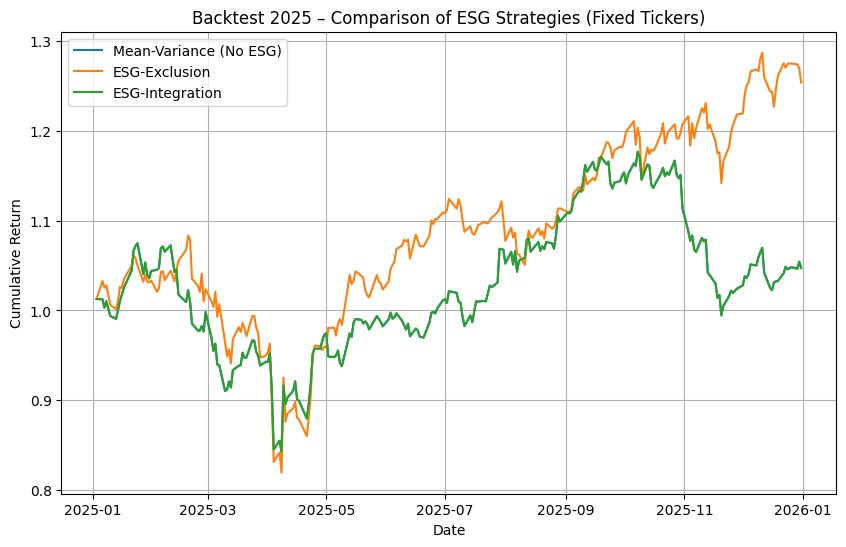

In [ ]:
# Parametri globali
TRADING_DAYS = 252
ESG_THRESHOLD = 0.5    # Soglia per la strategia ESG-Exclusion
ZETA = 0.01            # ESG tilt parameter per la strategia ESG-Integration
RISK_FREE_RATE = 0.01  # Tasso risk-free usato nella mean-variance

#path
df_prices = pd.read_csv(price_file_path, parse_dates=["Date"], index_col="Date")
df_prices.sort_index(inplace=True)

fixed_tickers = [
    'GLW', 'TER', 'TEL', 'CDW', 'ROP', 'AKAM', 'FTNT', 'VRSN',
    'ADI', 'MSI', 'CRM', 'ANSS', 'JNPR', 'AMAT', 'NOW', 'ADSK',
    'NXPI', 'INTU', 'SNPS', 'MU'
]

available_tickers = [t for t in fixed_tickers if t in df_prices.columns]

df_prices = df_prices[available_tickers]

#path
df_esg = pd.read_csv(esg_file_path)
df_esg_fixed = df_esg[df_esg['Symbol'].isin(available_tickers)].copy()

df_esg_fixed.sort_values('Symbol', inplace=True)
df_esg_fixed.reset_index(drop=True, inplace=True)

min_esg = df_esg_fixed['totalEsg'].min()
max_esg = df_esg_fixed['totalEsg'].max()
df_esg_fixed['normalized_ESG'] = (df_esg_fixed['totalEsg'] - min_esg) / (max_esg - min_esg)
df_esg_fixed.set_index('Symbol', inplace=True)

def portfolio_performance(weights, daily_returns, annualize_factor):
    mean_daily_ret = daily_returns.mean()
    port_return = np.sum(mean_daily_ret * weights) * annualize_factor
    port_cov = daily_returns.cov() * annualize_factor
    port_vol = np.sqrt(np.dot(weights.T, np.dot(port_cov, weights)))
    return port_return, port_vol

def negative_sharpe_ratio(weights, daily_returns, annualize_factor, rf=0.0):
    ret, vol = portfolio_performance(weights, daily_returns, annualize_factor)
    return -(ret - rf) / vol

def get_weights_mean_variance(daily_returns, annualize_factor, rf=0.0):
    num_assets = len(daily_returns.columns)
    init_w = np.array([1/num_assets]*num_assets)
    bounds = [(0,1)]*num_assets
    constraints = [{'type':'eq','fun': lambda x: np.sum(x) - 1}]

    result = minimize(
        fun=negative_sharpe_ratio,
        x0=init_w,
        args=(daily_returns, annualize_factor, rf),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result.x

def get_weights_esg_exclusion(daily_returns, annualize_factor, esg_df, threshold=0.5):
    eligible_symbols = esg_df[esg_df['normalized_ESG'] >= threshold].index.tolist()
    valid_symbols = [t for t in eligible_symbols if t in daily_returns.columns]

    weights = np.zeros(len(daily_returns.columns))
    if len(valid_symbols) > 0:
        w = 1.0/len(valid_symbols)
        for i, col in enumerate(daily_returns.columns):
            if col in valid_symbols:
                weights[i] = w
    return weights

def get_weights_esg_integration(daily_returns, annualize_factor, esg_df, zeta=0.01):
    mu_annual = daily_returns.mean()*annualize_factor
    Sigma_annual = daily_returns.cov()*annualize_factor
    normalized = esg_df.loc[mu_annual.index, 'normalized_ESG']
    mu_mod = mu_annual + zeta*normalized

    def neg_sharpe_ratio_integration(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w, np.dot(Sigma, w)))
        return -(ret / vol)

    init_w = np.array([1/len(mu_mod)]*len(mu_mod))
    bounds = [(0,1)]*len(mu_mod)
    constraints = [{'type':'eq','fun': lambda x: np.sum(x) - 1}]

    res = minimize(
        neg_sharpe_ratio_integration,
        init_w,
        args=(mu_mod.values, Sigma_annual),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return res.x

# PREPARAZIONE DEI DATI PER TRAIN (2023) E TEST (2024)

# training on 2024 data
df_prices_2024 = df_prices.loc["2024-01-01":"2024-12-31"]
train_returns_2024 = df_prices_2024.pct_change().dropna()

# test on 2025 data
df_prices_2025 = df_prices.loc["2025-01-01":"2025-12-31"]
test_returns_2025 = df_prices_2025.pct_change().dropna()

if df_prices_2025.empty:
    print("Attenzione: non ci sono dati di prezzo per il 2025 nel dataset!")

print("\nCostruzione dei portafogli su dati 2024...\n")
# a) Mean-Variance (without ESG)
weights_mv = get_weights_mean_variance(train_returns_2024, len(train_returns_2024), RISK_FREE_RATE)

# b) ESG-Exclusion
weights_excl = get_weights_esg_exclusion(train_returns_2024, len(train_returns_2024), df_esg_fixed, ESG_THRESHOLD)

# c) ESG-Integration
weights_integration = get_weights_esg_integration(train_returns_2024, len(train_returns_2024), df_esg_fixed, ZETA)


# BACKTEST SUI DATI 2025

common_tickers = available_tickers

w_dict_mv = dict(zip(train_returns_2024.columns, weights_mv))
w_dict_excl = dict(zip(train_returns_2024.columns, weights_excl))
w_dict_int = dict(zip(train_returns_2024.columns, weights_integration))

w_mv_2025 = np.array([w_dict_mv.get(t, 0.0) for t in common_tickers])
w_excl_2025 = np.array([w_dict_excl.get(t, 0.0) for t in common_tickers])
w_int_2025 = np.array([w_dict_int.get(t, 0.0) for t in common_tickers])

if w_mv_2025.sum() > 0:
    w_mv_2025 /= w_mv_2025.sum()
if w_excl_2025.sum() > 0:
    w_excl_2025 /= w_excl_2025.sum()
if w_int_2025.sum() > 0:
    w_int_2025 /= w_int_2025.sum()


daily_returns_2025 = test_returns_2025[common_tickers].copy()

port_ret_mv_2025 = (daily_returns_2025 * w_mv_2025).sum(axis=1)
port_ret_excl_2025 = (daily_returns_2025 * w_excl_2025).sum(axis=1)
port_ret_int_2025 = (daily_returns_2025 * w_int_2025).sum(axis=1)

def annual_stats(portfolio_returns):
    total_ret = (1+portfolio_returns).prod() - 1
    ann_ret = (1+portfolio_returns).prod()**(TRADING_DAYS/len(portfolio_returns)) - 1
    ann_vol = portfolio_returns.std()*np.sqrt(TRADING_DAYS)
    sharpe = (portfolio_returns.mean()/portfolio_returns.std())*np.sqrt(TRADING_DAYS) if portfolio_returns.std() != 0 else 0
    return total_ret, ann_ret, ann_vol, sharpe

mv_total, mv_ann, mv_vol, mv_sharpe = annual_stats(port_ret_mv_2025)
ex_total, ex_ann, ex_vol, ex_sharpe = annual_stats(port_ret_excl_2025)
int_total, int_ann, int_vol, int_sharpe = annual_stats(port_ret_int_2025)

print("\n===== BACKTEST 2025 RESULTS =====")
print("Mean-Variance (no ESG) => "
      f"Total Ret: {mv_total:.2%}, Annual Ret: {mv_ann:.2%}, Vol: {mv_vol:.2%}, Sharpe: {mv_sharpe:.2f}")
print("ESG-Exclusion => "
      f"Total Ret: {ex_total:.2%}, Annual Ret: {ex_ann:.2%}, Vol: {ex_vol:.2%}, Sharpe: {ex_sharpe:.2f}")
print("ESG-Integration => "
      f"Total Ret: {int_total:.2%}, Annual Ret: {int_ann:.2%}, Vol: {int_vol:.2%}, Sharpe: {int_sharpe:.2f}")

cum_mv = (1+port_ret_mv_2025).cumprod()
cum_excl = (1+port_ret_excl_2025).cumprod()
cum_int = (1+port_ret_int_2025).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cum_mv.index, cum_mv.values, label='Mean-Variance (No ESG)')
plt.plot(cum_excl.index, cum_excl.values, label='ESG-Exclusion')
plt.plot(cum_int.index, cum_int.values, label='ESG-Integration')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Backtest 2025 – Comparison of ESG Strategies (Fixed Tickers)')
plt.legend()
plt.grid(True)
plt.show()


This work was completed as part of a group project for the "ESG investing" course within the Master in Finance, Insurance and Risk management at Collegio Carlo Alberto and was also published on "Q markets Society", a student society founded by a group of students from the program.